# Disease and Retail Availability Data Cleaning

This notebook cleans the California COPD prevalence data from the CDC API and the retail availability of electronic smoking devices dataset. It preserves the raw data, writes cleaned interim files, merges the datasets at the county level, and exports a final analysis-ready CSV.

In [68]:
from pathlib import Path
import seaborn as sns
import pandas as pd
import requests
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 50)

PROJECT_DIR = Path.cwd()
if PROJECT_DIR.name != "disease_data":
    PROJECT_DIR = PROJECT_DIR / "disease_data"

RAW_DIR = PROJECT_DIR / "data" / "raw"
INTERIM_DIR = PROJECT_DIR / "data" / "interim"
PROCESSED_DIR = PROJECT_DIR / "data" / "processed"

INTERIM_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

RETAIL_RAW_FILE = RAW_DIR / "retail-availability-of-electronic-smoking-devices-by-county.csv"
COPD_INTERIM_FILE = INTERIM_DIR / "copd_ca_county_clean.csv"
RETAIL_INTERIM_FILE = INTERIM_DIR / "retail_esd_availability_clean.csv"
MERGED_PROCESSED_FILE = PROCESSED_DIR / "ca_county_copd_retail_esd_merged.csv"

In [69]:
def normalize_county_name(value):
    """Standardize county names for joining while keeping readable labels elsewhere."""
    if pd.isna(value):
        return pd.NA

    text = str(value).strip()
    text = " ".join(text.split())

    if text.lower().endswith(" county"):
        text = text[:-7].strip()

    return text.title()


def summarize_missing(df):
    return df.isna().sum().rename("missing_count").to_frame()

## Load and Clean COPD Data

In [70]:
copd_url = "https://data.cdc.gov/resource/i46a-9kgh.json"
copd_params = {
    "$limit": 5000,
    "$select": "stateabbr,countyname,countyfips,COPD_AdjPrev",
    "stateabbr": "CA",
}

response = requests.get(copd_url, params=copd_params, timeout=30)
response.raise_for_status()

copd_raw = pd.DataFrame(response.json())
copd_raw.head()

,stateabbr,countyname,countyfips,COPD_AdjPrev
0,CA,Solano,06095,4.6
1,CA,Placer,06061,4.2
2,CA,Kings,06031,6.1
3,CA,Fresno,06019,5.8
4,CA,Amador,06005,5.2


In [71]:
copd_clean = (
    copd_raw.rename(
        columns={
            "stateabbr": "state",
            "countyname": "county",
            "countyfips": "county_fips",
            "COPD_AdjPrev": "copd_adjusted_prevalence_pct",
        }
    )
    .assign(
        county=lambda df: df["county"].map(normalize_county_name),
        county_fips=lambda df: df["county_fips"].astype("string").str.zfill(5),
        copd_adjusted_prevalence_pct=lambda df: pd.to_numeric(
            df["copd_adjusted_prevalence_pct"], errors="coerce"
        ),
    )
    .dropna(subset=["county", "county_fips", "copd_adjusted_prevalence_pct"])
    .drop_duplicates(subset=["county_fips"])
    .sort_values("county")
    .reset_index(drop=True)
)

copd_clean.to_csv(COPD_INTERIM_FILE, index=False)
copd_clean.head()

,state,county,county_fips,copd_adjusted_prevalence_pct
0,CA,Alameda,06001,3.8
1,CA,Alpine,06003,4.7
2,CA,Amador,06005,5.2
3,CA,Butte,06007,6.2
4,CA,Calaveras,06009,5.9


## Load and Clean Retail Availability Data

In [72]:
retail_raw = pd.read_csv(RETAIL_RAW_FILE)
retail_raw.head()

,County,Year,Percentage
0,Alameda,2013,0.54
1,Alpine,2013,*
2,Amador,2013,0.3
3,Berkeley,2013,0.58
4,Butte,2013,0.47


In [ ]:
non_county_rows = {"Berkeley", "Long Beach", "Pasadena", "Statewide"}

retail_clean = (
    retail_raw.rename(
        columns={
            "County": "county",
            "Year": "year",
            "Percentage": "retail_esd_availability_pct",
        }
    )
    .assign(
        county=lambda df: df["county"].map(normalize_county_name),
        year=lambda df: pd.to_numeric(df["year"], errors="coerce").astype("Int64"),
        retail_esd_availability_pct=lambda df: pd.to_numeric(
            df["retail_esd_availability_pct"]
            .astype("string")
            .str.strip()
            .replace({"*": pd.NA, 0.0: pd.NA})
            .astype("Int64")
            .replace({0.0: pd.NA, df["retail_esd_availability_pct"].median(): pd.NA}),
            errors="coerce",
        ),
    )
)

retail_clean = (
    retail_clean.loc[
        (~retail_clean["county"].isin(non_county_rows))
        & (retail_clean["year"] == 2016)
    ]
    .dropna(subset=["county", "year"])
    .drop_duplicates(subset=["county"])
    .sort_values("county")
    .reset_index(drop=True)
)

retail_clean["retail_esd_availability_pct"] = retail_clean[
    "retail_esd_availability_pct"
].fillna(retail_clean["retail_esd_availability_pct"].median())


retail_clean = retail_clean[["county", "year", "retail_esd_availability_pct"]]

if retail_clean["county"].duplicated().any():
    raise ValueError("Retail cleaning still has duplicate county rows.")



retail_clean.to_csv(RETAIL_INTERIM_FILE, index=False)
retail_clean.head()

TypeError: Cannot perform reduction 'median' with string dtype

## Merge and Final Cleaning

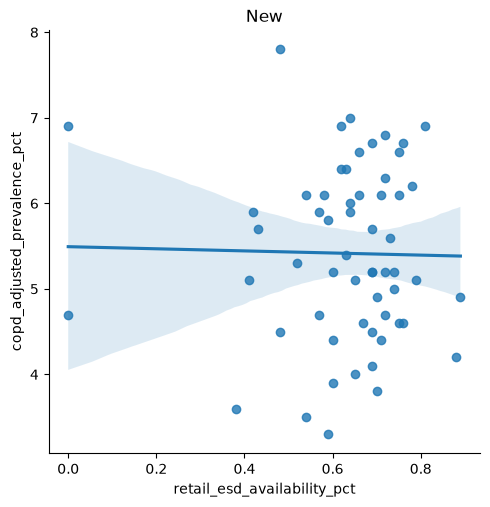

In [74]:
merged = retail_clean.merge(copd_clean, on="county", how="left", validate="one_to_one")

merged = (
    merged.assign(
        copd_adjusted_prevalence_pct=lambda df: df["copd_adjusted_prevalence_pct"].round(2),
        retail_esd_availability_pct=lambda df: df["retail_esd_availability_pct"].round(3),
    )
    [
        [
            "state",
            "county",
            "county_fips",
            "year",
            "retail_esd_availability_pct",
            "copd_adjusted_prevalence_pct",
        ]
    ]
    .sort_values("county")
    .reset_index(drop=True)
)

if merged["county"].duplicated().any():
    raise ValueError("Merged dataset still has duplicate county rows.")

if merged.isna().any().any():
    raise ValueError("Merged dataset still has missing values.")

merged = merged.drop(columns=['year', 'county_fips', 'state'])

merged.to_csv(MERGED_PROCESSED_FILE, index=False)
merged

sns.lmplot(x='retail_esd_availability_pct', y='copd_adjusted_prevalence_pct', data=merged)
plt.title('New')
plt.show()